<a href="https://colab.research.google.com/github/aniket-dev086/AQI_EDA/blob/main/AQI_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Quality Analysis – AQI and Pollution Trends

This Google Colab notebook analyzes the five uploaded city-wise AQI datasets: Bangalore, Chennai, Delhi, Hyderabad and Mumbai.

### Objectives
1. Clean and manipulate data
2. Generate summary statistics
3. Track AQI and pollutant trends over time
4. Compare pollutant distributions across cities
5. Perform correlation analysis
6. Analyze seasonal variation
7. Identify cities with higher average AQI
8. Analyze AQI categories

In [1]:
# Install/import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print('Libraries imported successfully.')

Libraries imported successfully.


## Upload the CSV files

Run the cell below and select all five CSV files from your computer.

In [2]:
uploaded = files.upload()
print('\nUploaded files:')
for filename in uploaded.keys():
    print(filename)

Saving Bangalore_AQI_Dataset.csv to Bangalore_AQI_Dataset.csv
Saving Chennai_AQI_Dataset.csv to Chennai_AQI_Dataset.csv
Saving Delhi_AQI_Dataset.csv to Delhi_AQI_Dataset.csv
Saving Hyderabad_AQI_Dataset.csv to Hyderabad_AQI_Dataset.csv
Saving Mumbai_AQI_Dataset.csv to Mumbai_AQI_Dataset.csv

Uploaded files:
Bangalore_AQI_Dataset.csv
Chennai_AQI_Dataset.csv
Delhi_AQI_Dataset.csv
Hyderabad_AQI_Dataset.csv
Mumbai_AQI_Dataset.csv


In [3]:
# Load and combine all uploaded CSV files
dataframes = []

for filename in uploaded.keys():
    if filename.lower().endswith('.csv'):
        temp = pd.read_csv(filename)
        temp.columns = temp.columns.str.replace('\ufeff', '', regex=False).str.strip()
        dataframes.append(temp)

aqi = pd.concat(dataframes, ignore_index=True)

print('Combined dataset shape:', aqi.shape)
display(aqi.head())

Combined dataset shape: (12042, 9)


,ï»¿City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,Bangalore,01/01/18,68.0,37.4,73.44,56.44,77.52,0.71,64.6
1,Bangalore,02/01/18,76.0,41.8,82.08,63.08,86.64,0.80,72.2
2,Bangalore,03/01/18,70.0,38.5,75.60,58.10,79.80,0.74,66.5
3,Bangalore,04/01/18,78.0,42.9,84.24,64.74,88.92,0.82,74.1
4,Bangalore,05/01/18,82.0,45.1,88.56,68.06,93.48,0.86,77.9


## 1. Data Cleaning and Manipulation

In [4]:
# Inspect the dataset
print('Columns:')
print(aqi.columns.tolist())

print('\nDataset information:')
aqi.info()

print('\nMissing values before cleaning:')
display(aqi.isnull().sum().to_frame('Missing Values'))

Columns:
['ï»¿City', 'Date', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12042 entries, 0 to 12041
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ï»¿City  12042 non-null  object 
 1   Date     12042 non-null  object 
 2   AQI      12041 non-null  float64
 3   PM2.5    12042 non-null  float64
 4   PM10     12042 non-null  float64
 5   NO2      12042 non-null  float64
 6   SO2      12042 non-null  float64
 7   CO       12042 non-null  float64
 8   O3       12042 non-null  float64
dtypes: float64(7), object(2)
memory usage: 846.8+ KB

Missing values before cleaning:


,Missing Values
ï»¿City,0
Date,0
AQI,1
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


In [7]:
# Clean column names first
aqi.columns = (
    aqi.columns
    .str.replace('\ufeff', '', regex=False)
    .str.replace('ï»¿', '', regex=False)
    .str.strip()
)

# Clean data types and missing values

# Clean City column
aqi['City'] = aqi['City'].astype(str).str.strip()

# Convert Date column
aqi['Date'] = pd.to_datetime(
    aqi['Date'],
    dayfirst=True,
    errors='coerce'
)

# Numerical columns
numeric_columns = [
    'AQI',
    'PM2.5',
    'PM10',
    'NO2',
    'SO2',
    'CO',
    'O3'
]

# Convert numerical columns to numeric
for col in numeric_columns:
    if col in aqi.columns:
        aqi[col] = pd.to_numeric(
            aqi[col],
            errors='coerce'
        )

        # Fill missing values with median
        aqi[col] = aqi[col].fillna(
            aqi[col].median()
        )

# Remove rows where City or Date is missing
aqi = aqi.dropna(
    subset=['City', 'Date']
)

# Sort by City and Date
aqi = aqi.sort_values(
    by=['City', 'Date']
).reset_index(drop=True)

# Display results
print("Missing values after cleaning:")
display(
    aqi.isnull().sum().to_frame(
        'Missing Values'
    )
)

print("\nData types:")
display(
    aqi.dtypes.to_frame(
        'Data Type'
    )
)

print("\nDataset shape:", aqi.shape)

print("\nCities:")
print(aqi['City'].unique())

/tmp/ipykernel_2475/400599202.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  aqi['Date'] = pd.to_datetime(


Missing values after cleaning:


,Missing Values
City,0
Date,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0



Data types:


,Data Type
City,object
Date,datetime64[ns]
AQI,float64
PM2.5,float64
PM10,float64
NO2,float64
SO2,float64
CO,float64
O3,float64



Dataset shape: (12042, 9)

Cities:
['Bangalore' 'Chennai' 'Delhi' 'Hyderabad' 'Mumbai']


## 2. Summary Statistics

In [8]:
# Mean, median and standard deviation by city
print('Mean values by city:')
display(aqi.groupby('City')[numeric_columns].mean().round(2))

print('Median values by city:')
display(aqi.groupby('City')[numeric_columns].median().round(2))

print('Standard deviation by city:')
display(aqi.groupby('City')[numeric_columns].std().round(2))

Mean values by city:


,AQI,PM2.5,PM10,NO2,SO2,CO,O3
City,,,,,,,
Bangalore,74.32,40.88,80.27,61.69,84.73,0.78,70.61
Chennai,77.34,42.52,83.49,64.16,88.13,0.81,73.44
Delhi,208.29,114.56,224.95,172.88,237.45,2.19,197.87
Hyderabad,85.40,46.97,92.23,70.88,97.36,0.90,81.13
Mumbai,106.78,58.73,115.33,88.63,121.73,1.12,101.44


Median values by city:


,AQI,PM2.5,PM10,NO2,SO2,CO,O3
City,,,,,,,
Bangalore,69.0,37.95,74.52,57.27,78.66,0.72,65.55
Chennai,69.0,37.95,74.52,57.27,78.66,0.72,65.55
Delhi,190.0,104.50,205.20,157.70,216.60,2.00,180.50
Hyderabad,82.0,45.10,88.56,68.06,93.48,0.86,77.90
Mumbai,90.0,49.50,97.20,74.70,102.60,0.95,85.50


Standard deviation by city:


,AQI,PM2.5,PM10,NO2,SO2,CO,O3
City,,,,,,,
Bangalore,25.76,14.17,27.82,21.38,29.36,0.27,24.47
Chennai,31.63,17.41,34.20,26.28,36.10,0.33,30.08
Delhi,106.61,58.64,115.14,88.49,121.54,1.12,101.28
Hyderabad,34.04,18.72,36.76,28.25,38.81,0.36,32.34
Mumbai,56.73,31.20,61.27,47.09,64.68,0.60,53.90


In [9]:
# IQR by city
q1 = aqi.groupby('City')[numeric_columns].quantile(0.25)
q3 = aqi.groupby('City')[numeric_columns].quantile(0.75)
iqr = q3 - q1

print('Interquartile Range (IQR) by city:')
display(iqr.round(2))

Interquartile Range (IQR) by city:


,AQI,PM2.5,PM10,NO2,SO2,CO,O3
City,,,,,,,
Bangalore,37.0,20.35,39.96,30.71,42.18,0.39,35.15
Chennai,32.0,17.60,34.56,26.56,36.48,0.33,30.40
Delhi,172.0,94.60,185.76,142.76,196.08,1.80,163.40
Hyderabad,51.0,28.05,55.08,42.33,58.14,0.53,48.45
Mumbai,87.0,47.85,93.96,72.21,99.18,0.91,82.65


## 3. AQI Trends Over Time

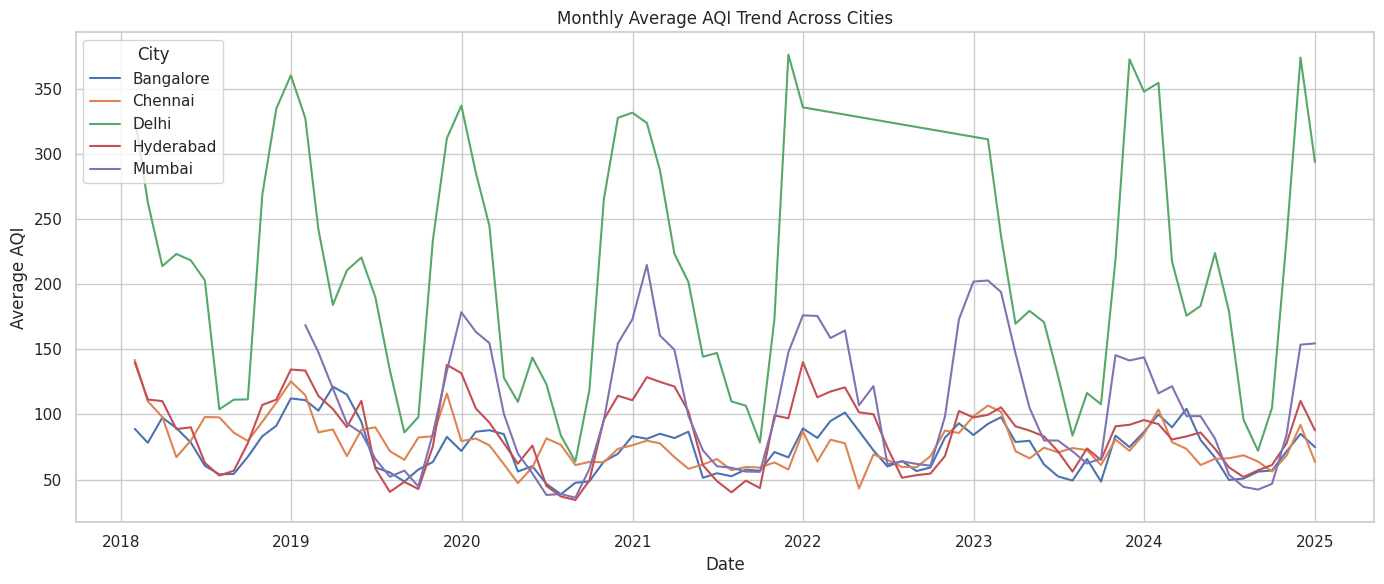

In [10]:
# Monthly AQI trend for all cities
monthly_aqi = (
    aqi.set_index('Date')
       .groupby('City')['AQI']
       .resample('ME')
       .mean()
       .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_aqi, x='Date', y='AQI', hue='City')
plt.title('Monthly Average AQI Trend Across Cities')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()

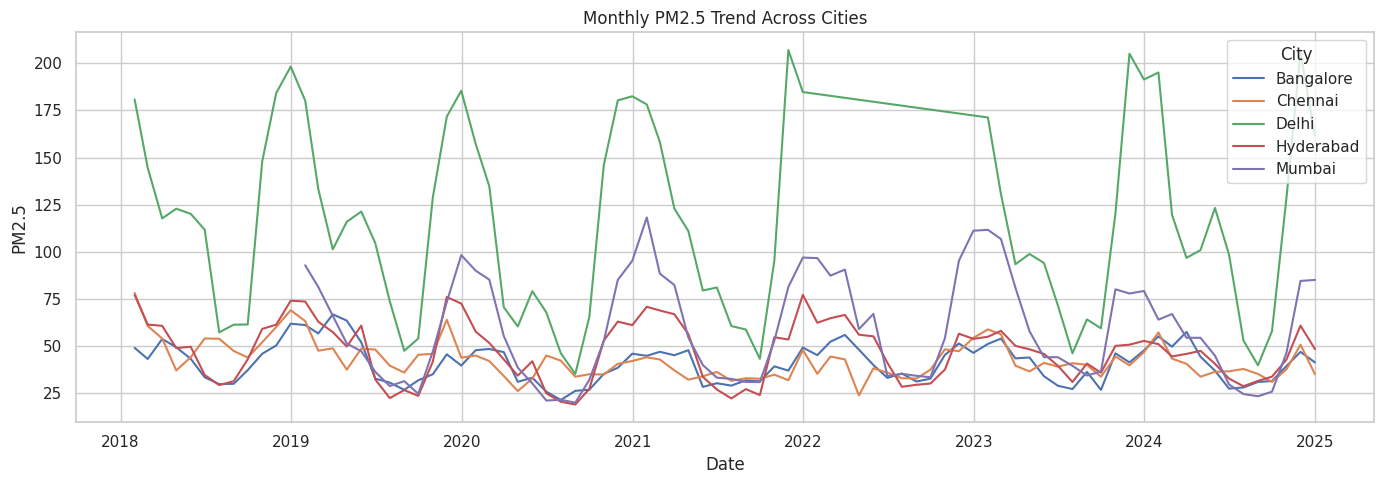

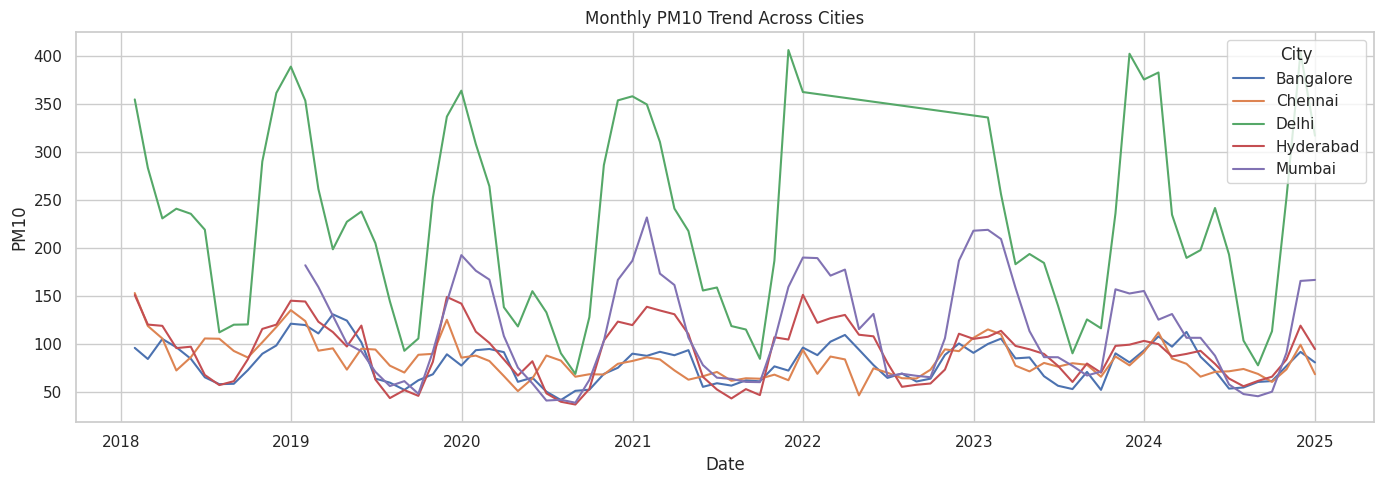

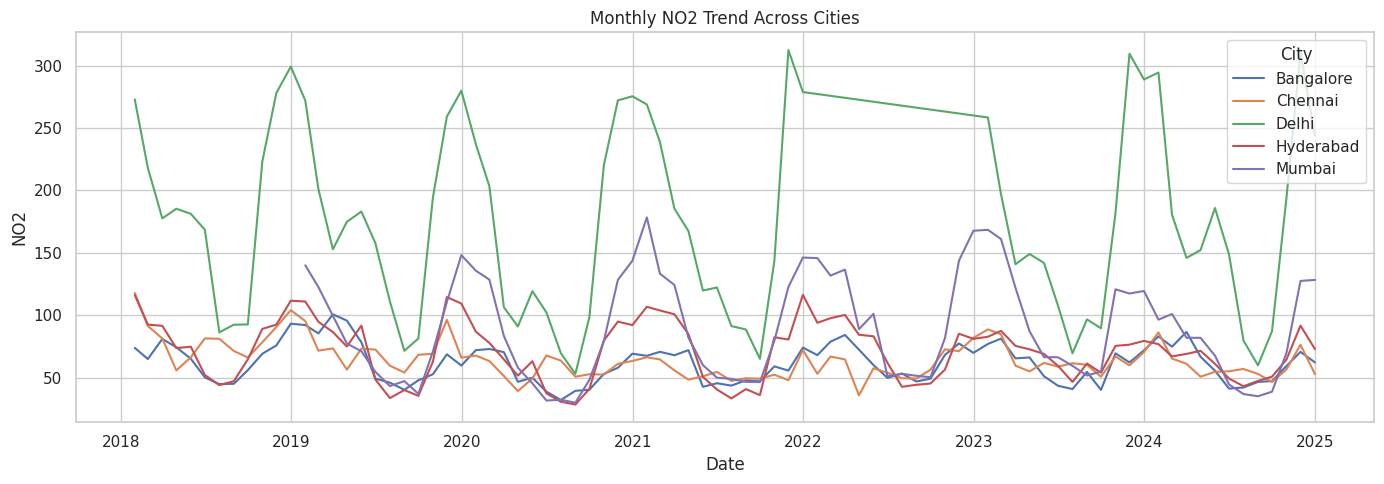

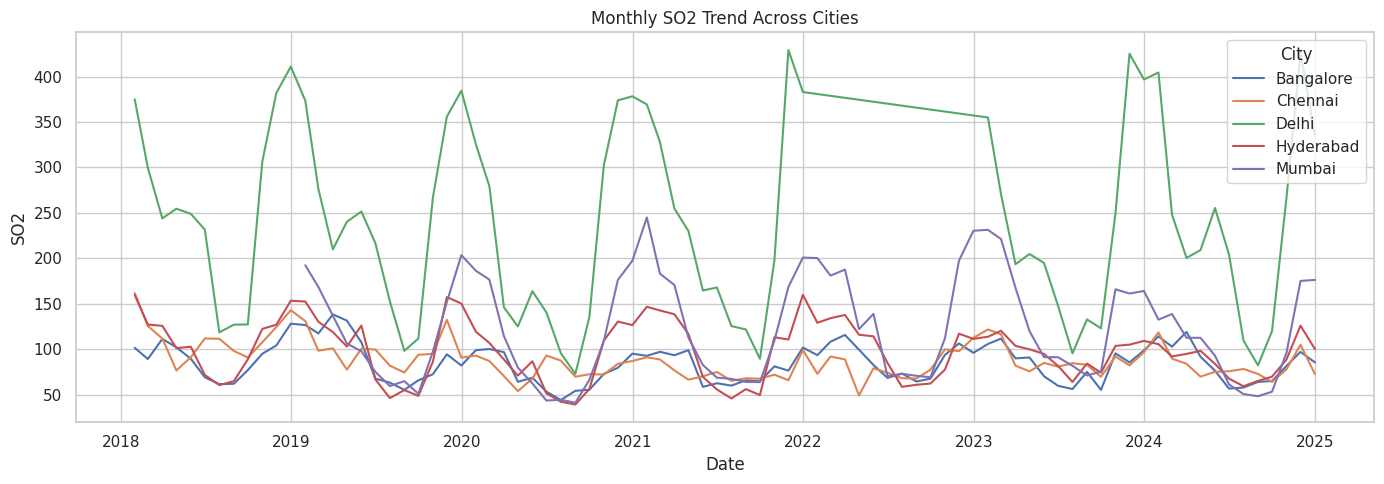

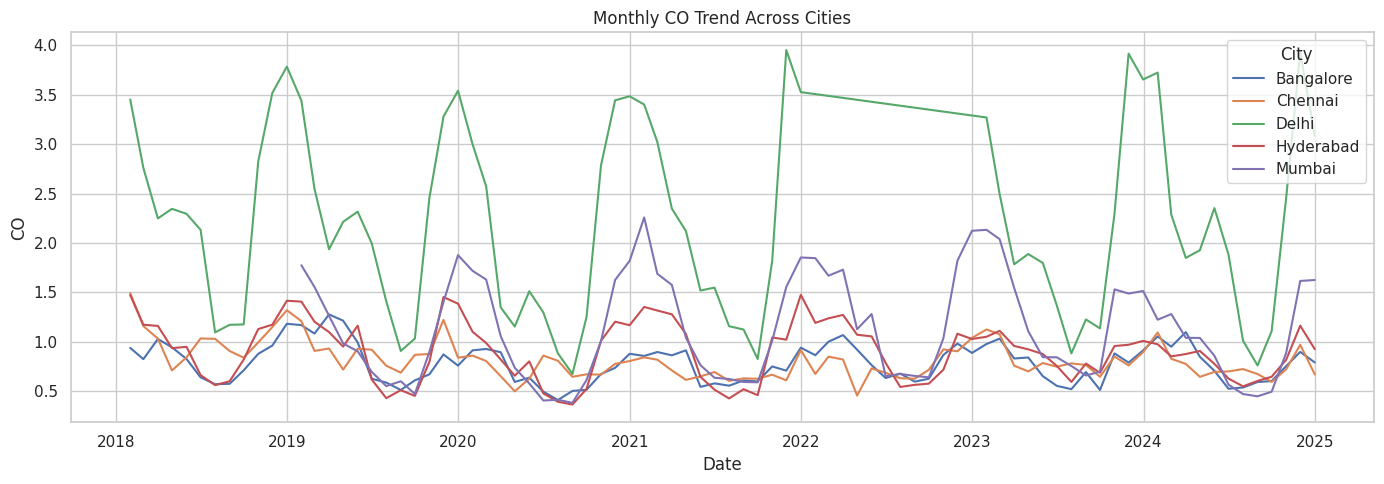

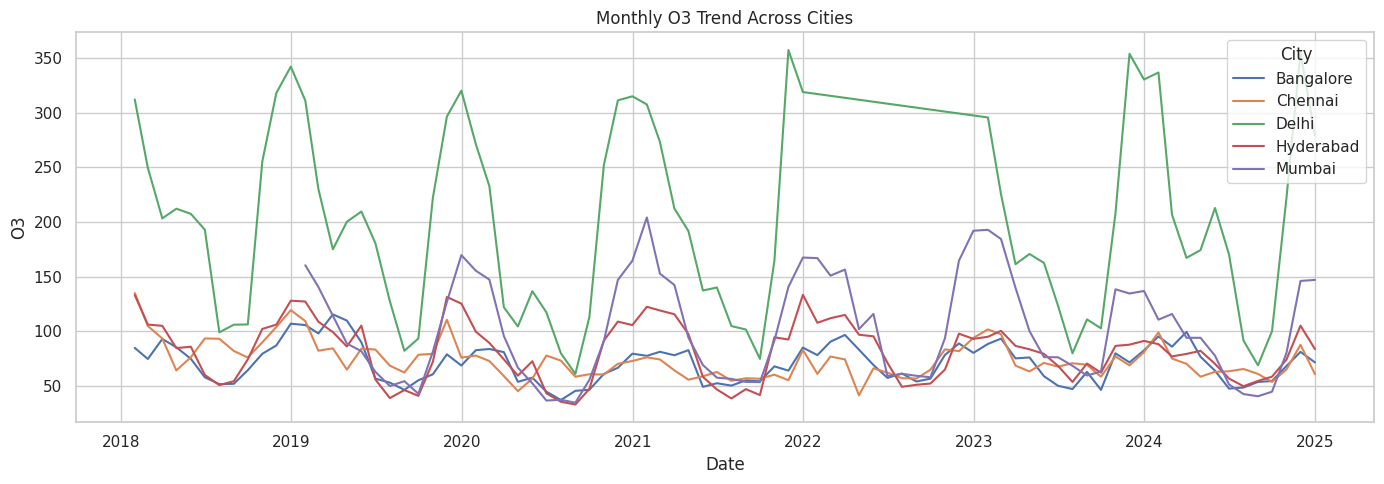

In [11]:
# Monthly trends for major pollutants
for pollutant in [p for p in ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'] if p in aqi.columns]:
    monthly_pollutant = (
        aqi.set_index('Date')
           .groupby('City')[pollutant]
           .resample('ME')
           .mean()
           .reset_index()
    )

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=monthly_pollutant, x='Date', y=pollutant, hue='City')
    plt.title(f'Monthly {pollutant} Trend Across Cities')
    plt.xlabel('Date')
    plt.ylabel(pollutant)
    plt.tight_layout()
    plt.show()

## 4. Pollutant Distributions Across Cities

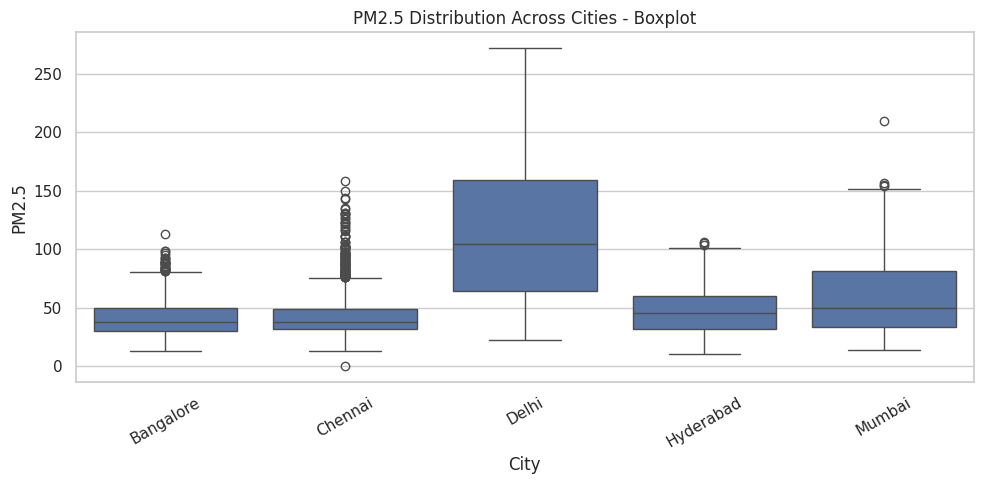

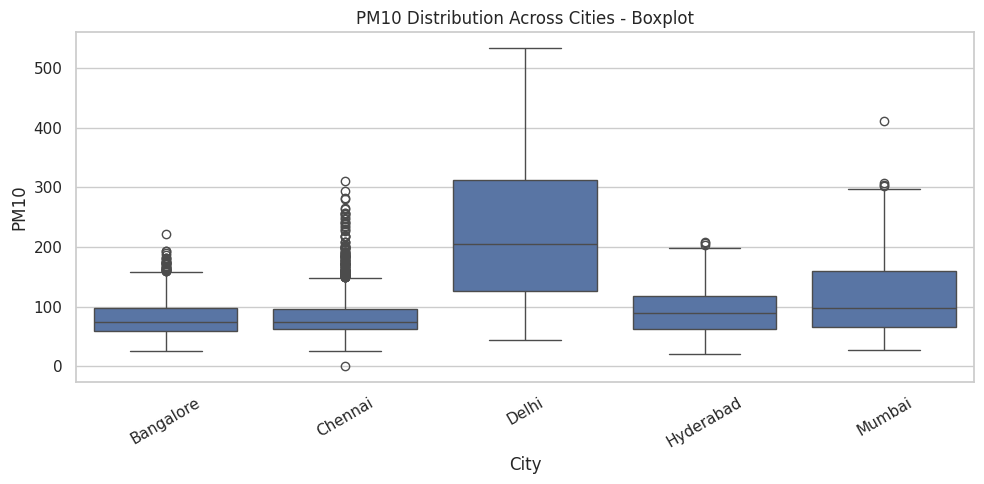

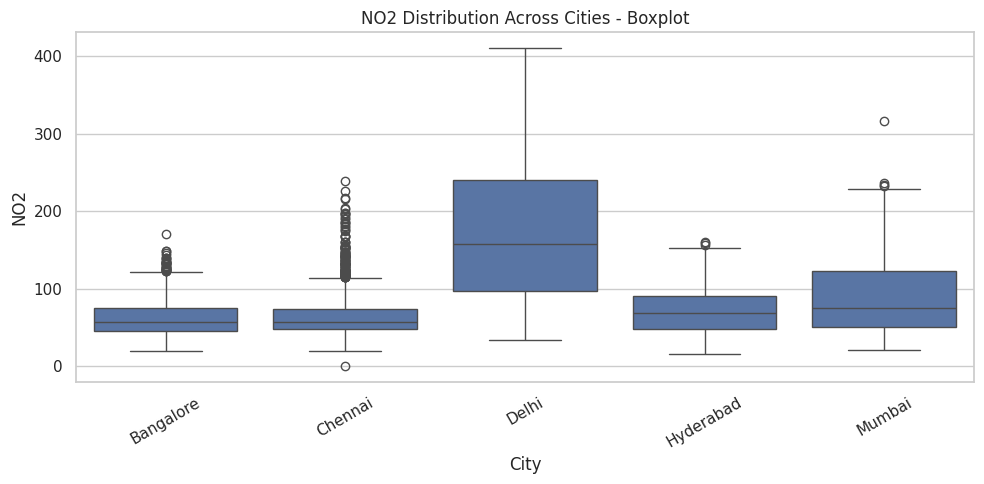

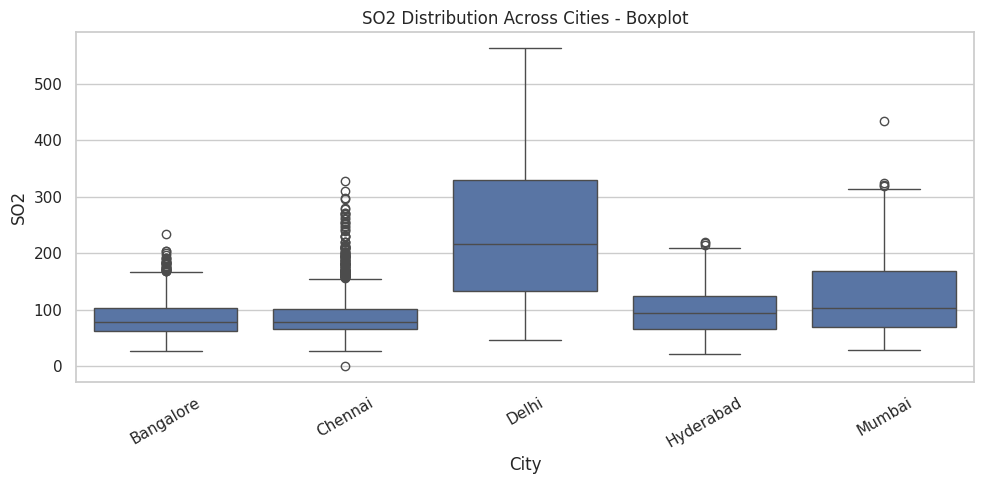

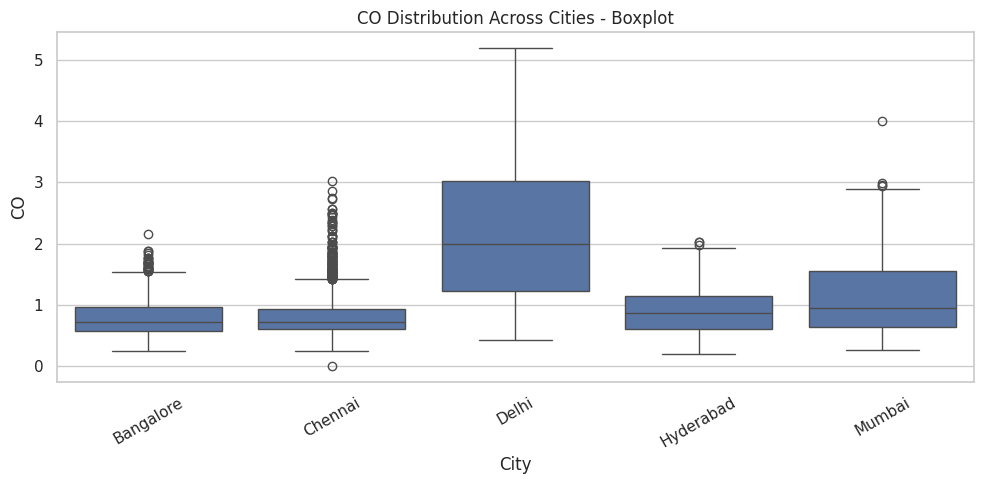

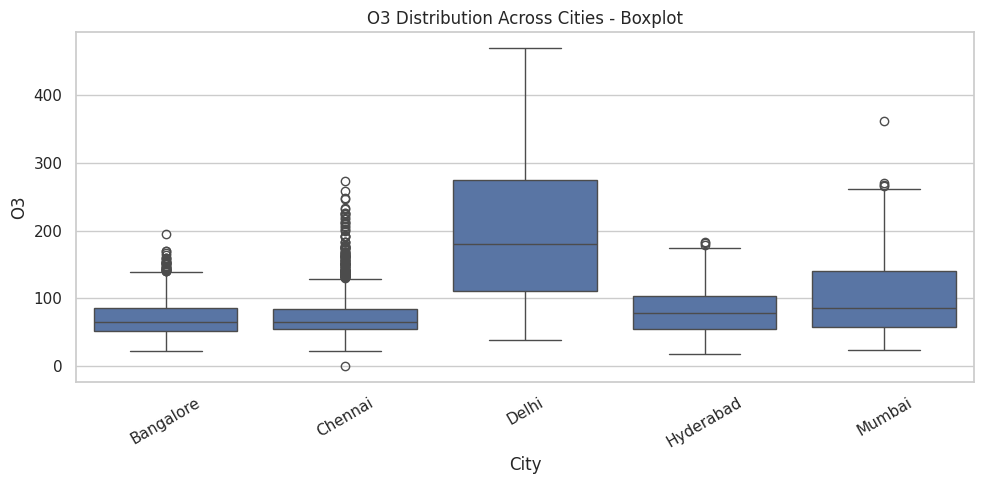

In [12]:
# Boxplots
for pollutant in [p for p in ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'] if p in aqi.columns]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=aqi, x='City', y=pollutant)
    plt.title(f'{pollutant} Distribution Across Cities - Boxplot')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

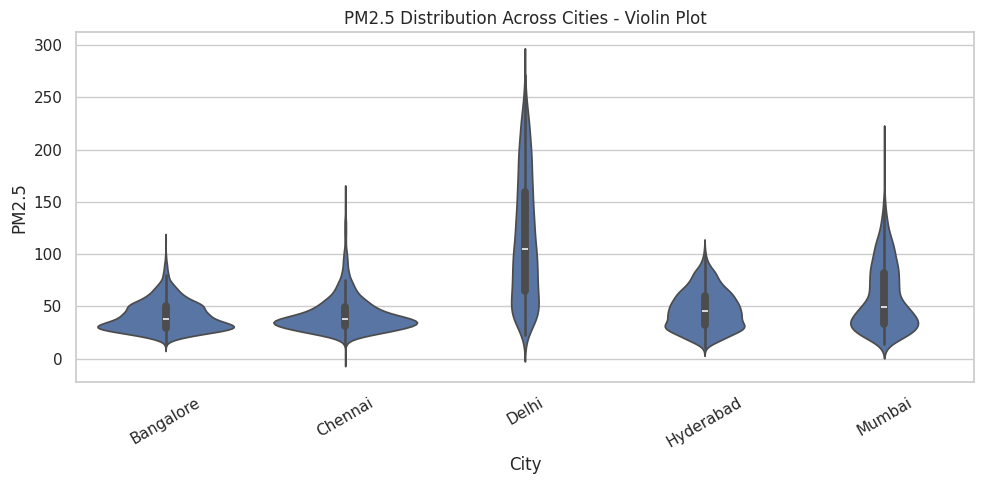

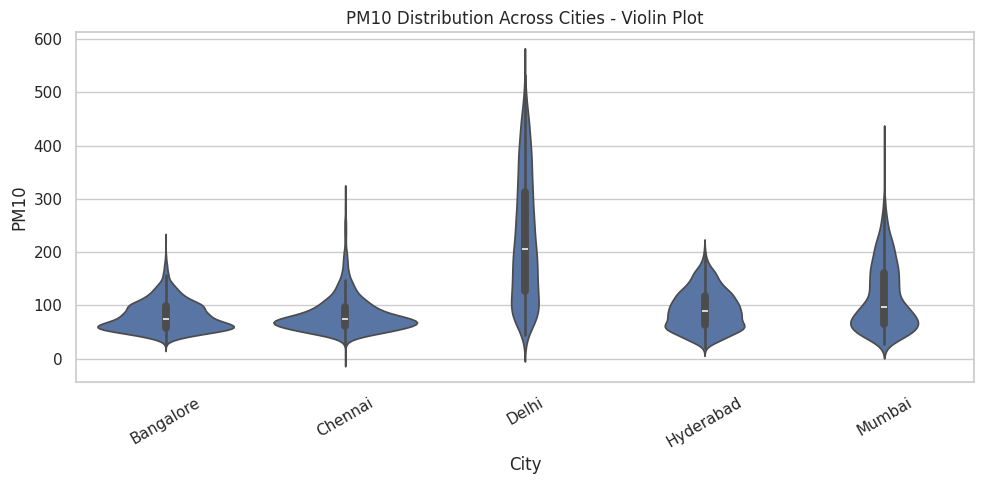

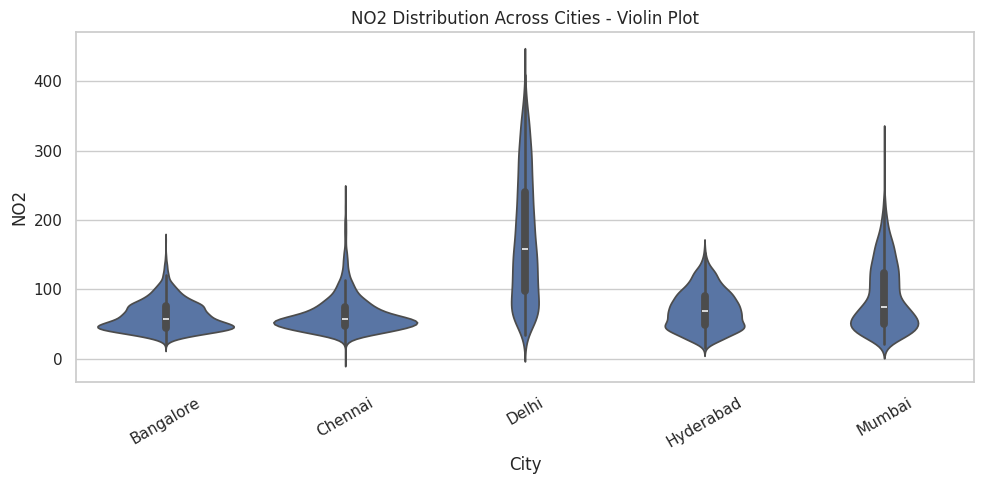

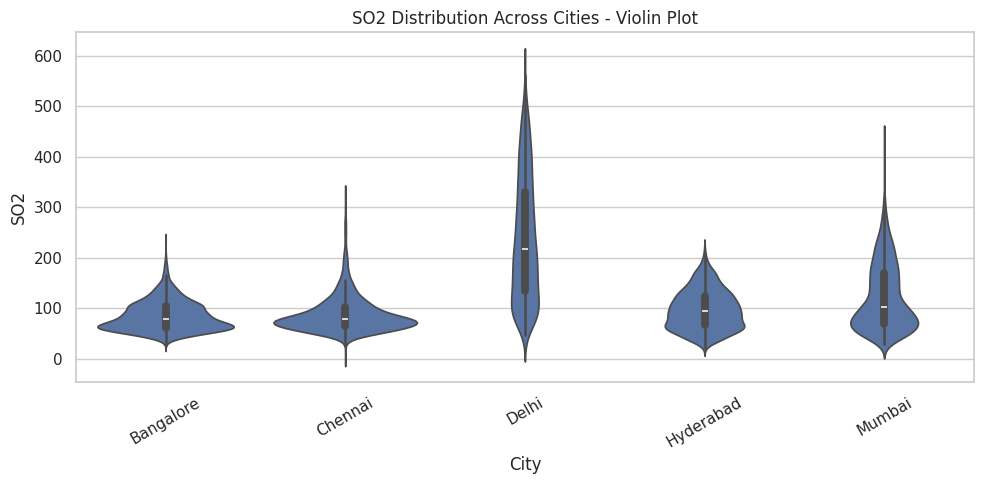

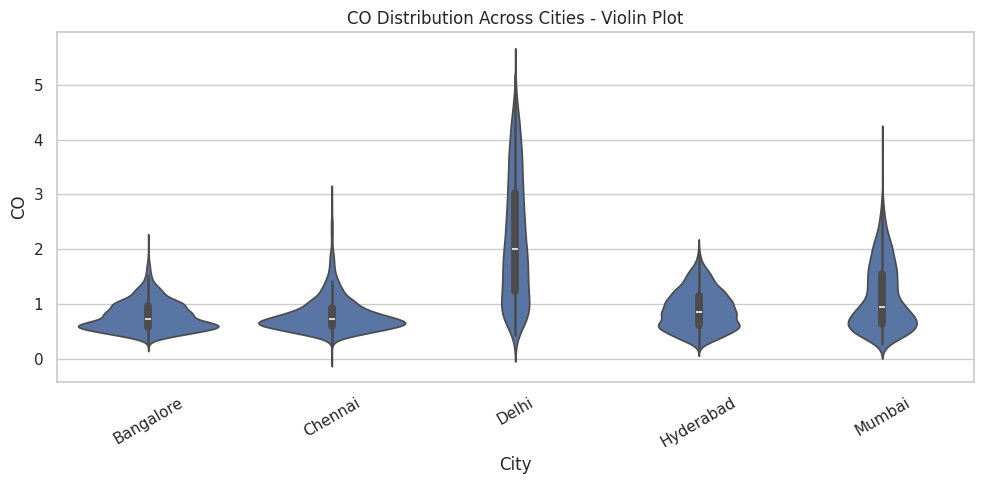

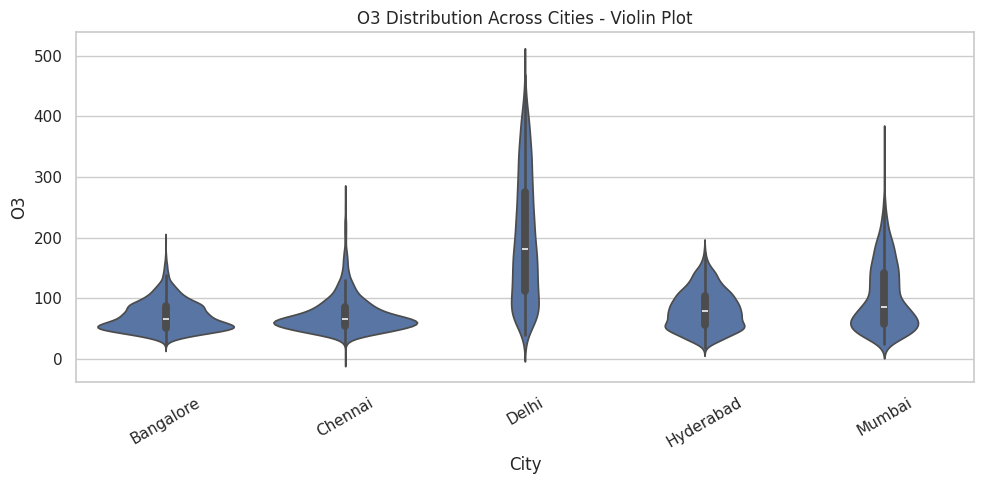

In [13]:
# Violin plots
for pollutant in [p for p in ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'] if p in aqi.columns]:
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=aqi, x='City', y=pollutant)
    plt.title(f'{pollutant} Distribution Across Cities - Violin Plot')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 5. Correlation Analysis

Correlation Matrix:


,AQI,PM2.5,PM10,NO2,SO2,CO,O3
AQI,1.0,1.0,1.0,1.0,1.0,1.0,1.0
PM2.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0
PM10,1.0,1.0,1.0,1.0,1.0,1.0,1.0
NO2,1.0,1.0,1.0,1.0,1.0,1.0,1.0
SO2,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CO,1.0,1.0,1.0,1.0,1.0,1.0,1.0
O3,1.0,1.0,1.0,1.0,1.0,1.0,1.0


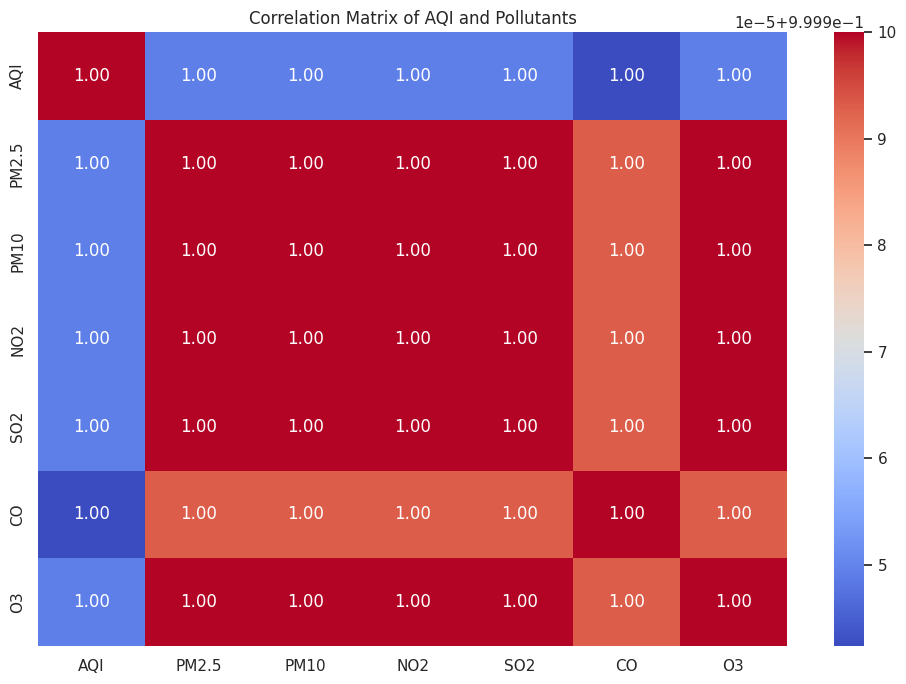

In [14]:
correlation_columns = [c for c in ['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'] if c in aqi.columns]
correlation = aqi[correlation_columns].corr()

print('Correlation Matrix:')
display(correlation.round(3))

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of AQI and Pollutants')
plt.tight_layout()
plt.show()

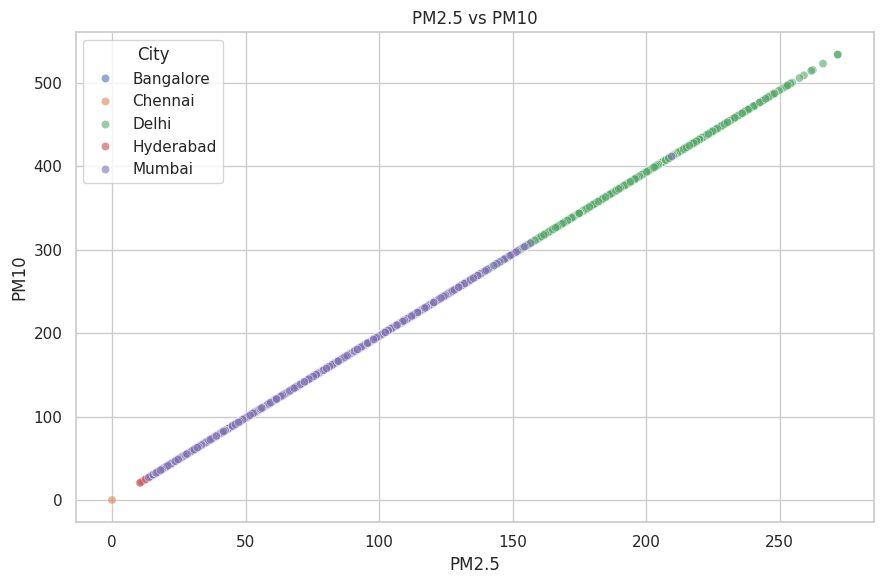

PM2.5 vs PM10 correlation: 1.0


In [15]:
# PM2.5 vs PM10
plt.figure(figsize=(9, 6))
sns.scatterplot(data=aqi, x='PM2.5', y='PM10', hue='City', alpha=0.6)
plt.title('PM2.5 vs PM10')
plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.tight_layout()
plt.show()

print('PM2.5 vs PM10 correlation:', round(aqi['PM2.5'].corr(aqi['PM10']), 3))

## 6. Seasonal Variation

In [16]:
aqi['Month'] = aqi['Date'].dt.month
aqi['Month_Name'] = aqi['Date'].dt.month_name()

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

aqi['Season'] = aqi['Month'].apply(get_season)

season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
seasonal_aqi = aqi.groupby(['City', 'Season'])['AQI'].mean().reset_index()
seasonal_aqi['Season'] = pd.Categorical(seasonal_aqi['Season'], categories=season_order, ordered=True)
seasonal_aqi = seasonal_aqi.sort_values('Season')

display(seasonal_aqi.pivot(index='City', columns='Season', values='AQI').round(2))

Season,Winter,Summer,Monsoon,Post-Monsoon
City,,,,
Bangalore,89.63,83.39,54.65,77.36
Chennai,91.59,69.13,70.74,81.88
Delhi,303.44,184.80,114.75,290.14
Hyderabad,112.51,91.59,54.17,98.48
Mumbai,167.44,102.83,55.71,125.36


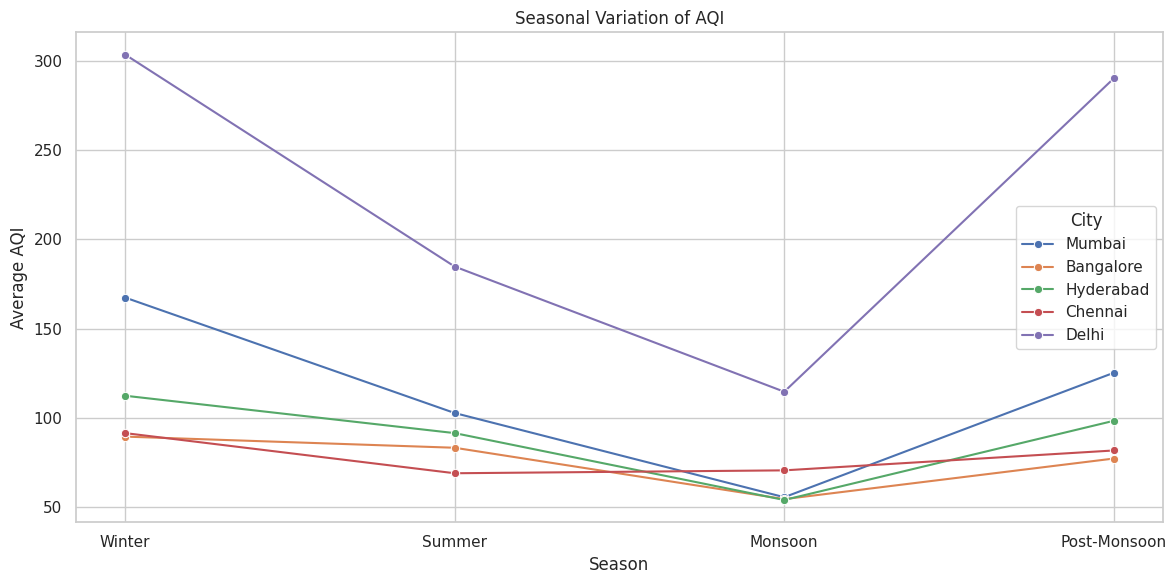

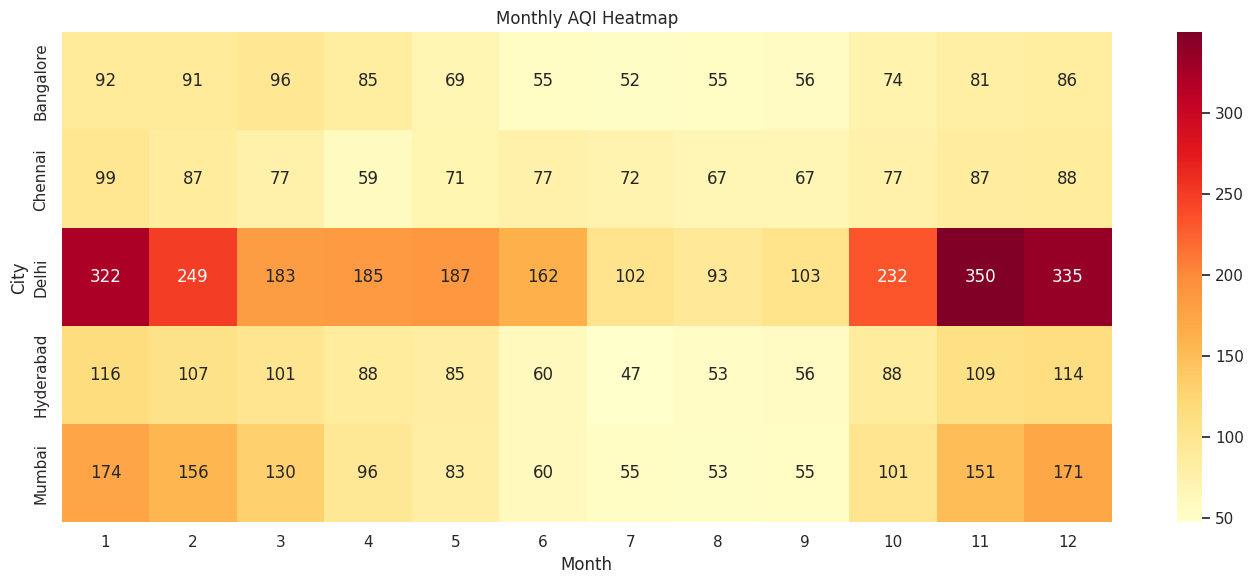

In [17]:
# Seasonal AQI lineplot
plt.figure(figsize=(12, 6))
sns.lineplot(data=seasonal_aqi, x='Season', y='AQI', hue='City', marker='o')
plt.title('Seasonal Variation of AQI')
plt.xlabel('Season')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()

# Monthly heatmap
monthly_city_aqi = aqi.groupby(['City', 'Month'])['AQI'].mean().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(monthly_city_aqi, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Monthly AQI Heatmap')
plt.xlabel('Month')
plt.ylabel('City')
plt.tight_layout()
plt.show()

## 7. Cities by Average AQI

Average AQI by city:


,Mean AQI
City,
Delhi,208.29
Mumbai,106.78
Hyderabad,85.40
Chennai,77.34
Bangalore,74.32


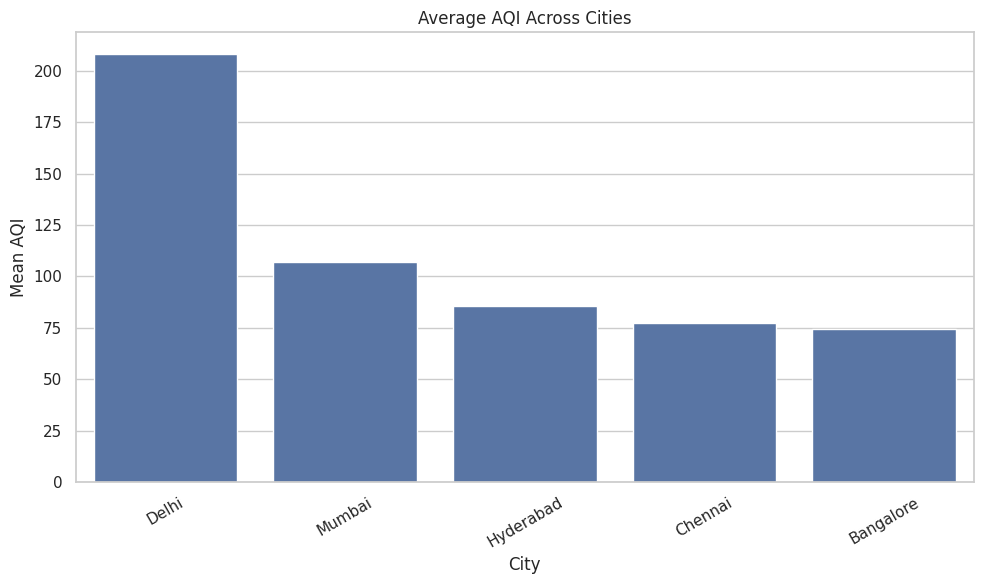

In [18]:
city_aqi = aqi.groupby('City')['AQI'].mean().sort_values(ascending=False)

print('Average AQI by city:')
display(city_aqi.round(2).to_frame('Mean AQI'))

plt.figure(figsize=(10, 6))
sns.barplot(x=city_aqi.index, y=city_aqi.values)
plt.title('Average AQI Across Cities')
plt.xlabel('City')
plt.ylabel('Mean AQI')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. AQI Category Analysis

In [19]:
def aqi_category(value):
    if value <= 50:
        return 'Good'
    elif value <= 100:
        return 'Satisfactory'
    elif value <= 200:
        return 'Moderate'
    elif value <= 300:
        return 'Poor'
    elif value <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

aqi['AQI_Category'] = aqi['AQI'].apply(aqi_category)

print('Overall AQI category frequency:')
display(aqi['AQI_Category'].value_counts().to_frame('Number of Days'))

print('AQI categories by city:')
category_city = pd.crosstab(aqi['City'], aqi['AQI_Category'])
display(category_city)

Overall AQI category frequency:


,Number of Days
AQI_Category,
Satisfactory,6103
Moderate,3189
Good,1540
Poor,713
Very Poor,381
Severe,116


AQI categories by city:


AQI_Category,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
City,,,,,,
Bangalore,444,403,1,1708,0,0
Chennai,348,402,25,1776,0,0
Delhi,9,759,523,404,116,380
Hyderabad,419,832,0,1305,0,0
Mumbai,320,793,164,910,0,1


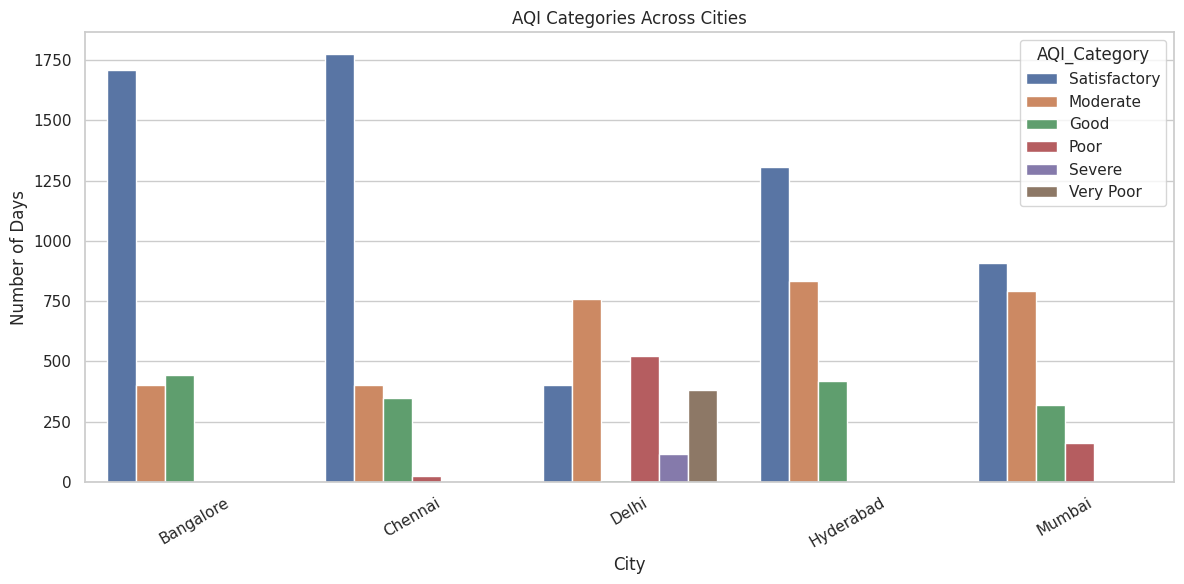

AQI categories by season:


AQI_Category,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
Season,,,,,,
Monsoon,1092,411,44,2468,3,5
Post-Monsoon,181,648,141,862,52,129
Summer,173,914,209,1722,0,16
Winter,94,1216,319,1051,61,231


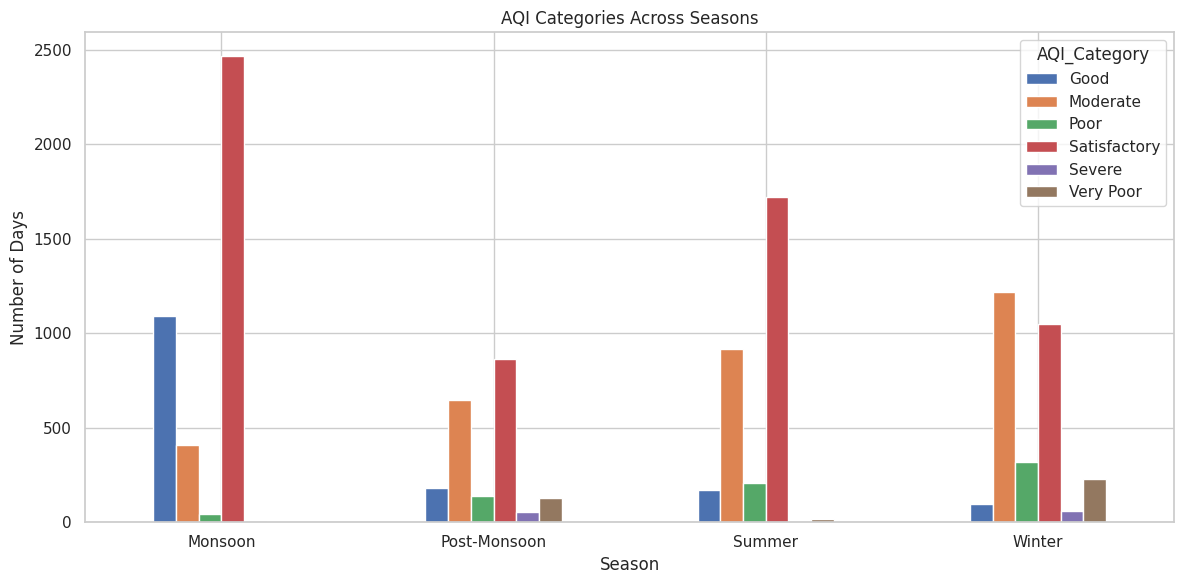

In [20]:
# AQI category visualization by city
plt.figure(figsize=(12, 6))
sns.countplot(data=aqi, x='City', hue='AQI_Category')
plt.title('AQI Categories Across Cities')
plt.xlabel('City')
plt.ylabel('Number of Days')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# AQI category by season
season_category = pd.crosstab(aqi['Season'], aqi['AQI_Category'])
print('AQI categories by season:')
display(season_category)

season_category.plot(kind='bar', figsize=(12, 6))
plt.title('AQI Categories Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Final Summary

In [21]:
print('================ FINAL RESULTS ================')
print('Total records:', len(aqi))
print('Cities:', ', '.join(sorted(aqi['City'].unique())))
print('Date range:', aqi['Date'].min().date(), 'to', aqi['Date'].max().date())

print('\nMean AQI by city:')
display(city_aqi.round(2).to_frame('Mean AQI'))

print('\nMost frequent AQI category:', aqi['AQI_Category'].value_counts().idxmax())

print('\nStrongest pollutant correlations:')
corr_pairs = correlation.where(~np.eye(correlation.shape[0], dtype=bool)).stack()
corr_pairs = corr_pairs.sort_values(ascending=False)
display(corr_pairs.head(10).to_frame('Correlation'))

================ FINAL RESULTS ================
Total records: 12042
Cities: Bangalore, Chennai, Delhi, Hyderabad, Mumbai
Date range: 2018-01-01 to 2024-12-31

Mean AQI by city:


,Mean AQI
City,
Delhi,208.29
Mumbai,106.78
Hyderabad,85.40
Chennai,77.34
Bangalore,74.32



Most frequent AQI category: Satisfactory

Strongest pollutant correlations:


,,Correlation
SO2,PM10,1.0
PM10,SO2,1.0
O3,SO2,1.0
SO2,O3,1.0
NO2,O3,1.0
O3,NO2,1.0
SO2,NO2,1.0
NO2,SO2,1.0
PM10,NO2,1.0
NO2,PM10,1.0
